Cell 1 — Imports and load data:

In [11]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
import os
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=True)

# Load annotated data
adata = sc.read_h5ad(os.path.expanduser("~/ATRT/Data/adata_annotated.h5ad"))
print(f"Loaded: {adata.n_obs} nuclei x {adata.n_vars} genes")
print(f"Cell types: {adata.obs['cell_type'].unique().tolist()}")
print(f"Raw counts available: {adata.raw is not None}")

Loaded: 9604 nuclei x 36601 genes
Cell types: ['Tumor_Unannotated', 'Tumor_Mesenchymal', 'Tumor_CP-like', 'Neurons', 'Tumor_IPC-like', 'Pericytes', 'Tumor_Cilia-like', 'Tumor_NPC-like', 'Microglia', 'Tumor_Hypoxic', 'Astrocytes', 'Tumor_OPC-like', 'Endothelial']
Raw counts available: True


Cell 2 — ZMYM3 UMAP feature plot (Figure 2D):

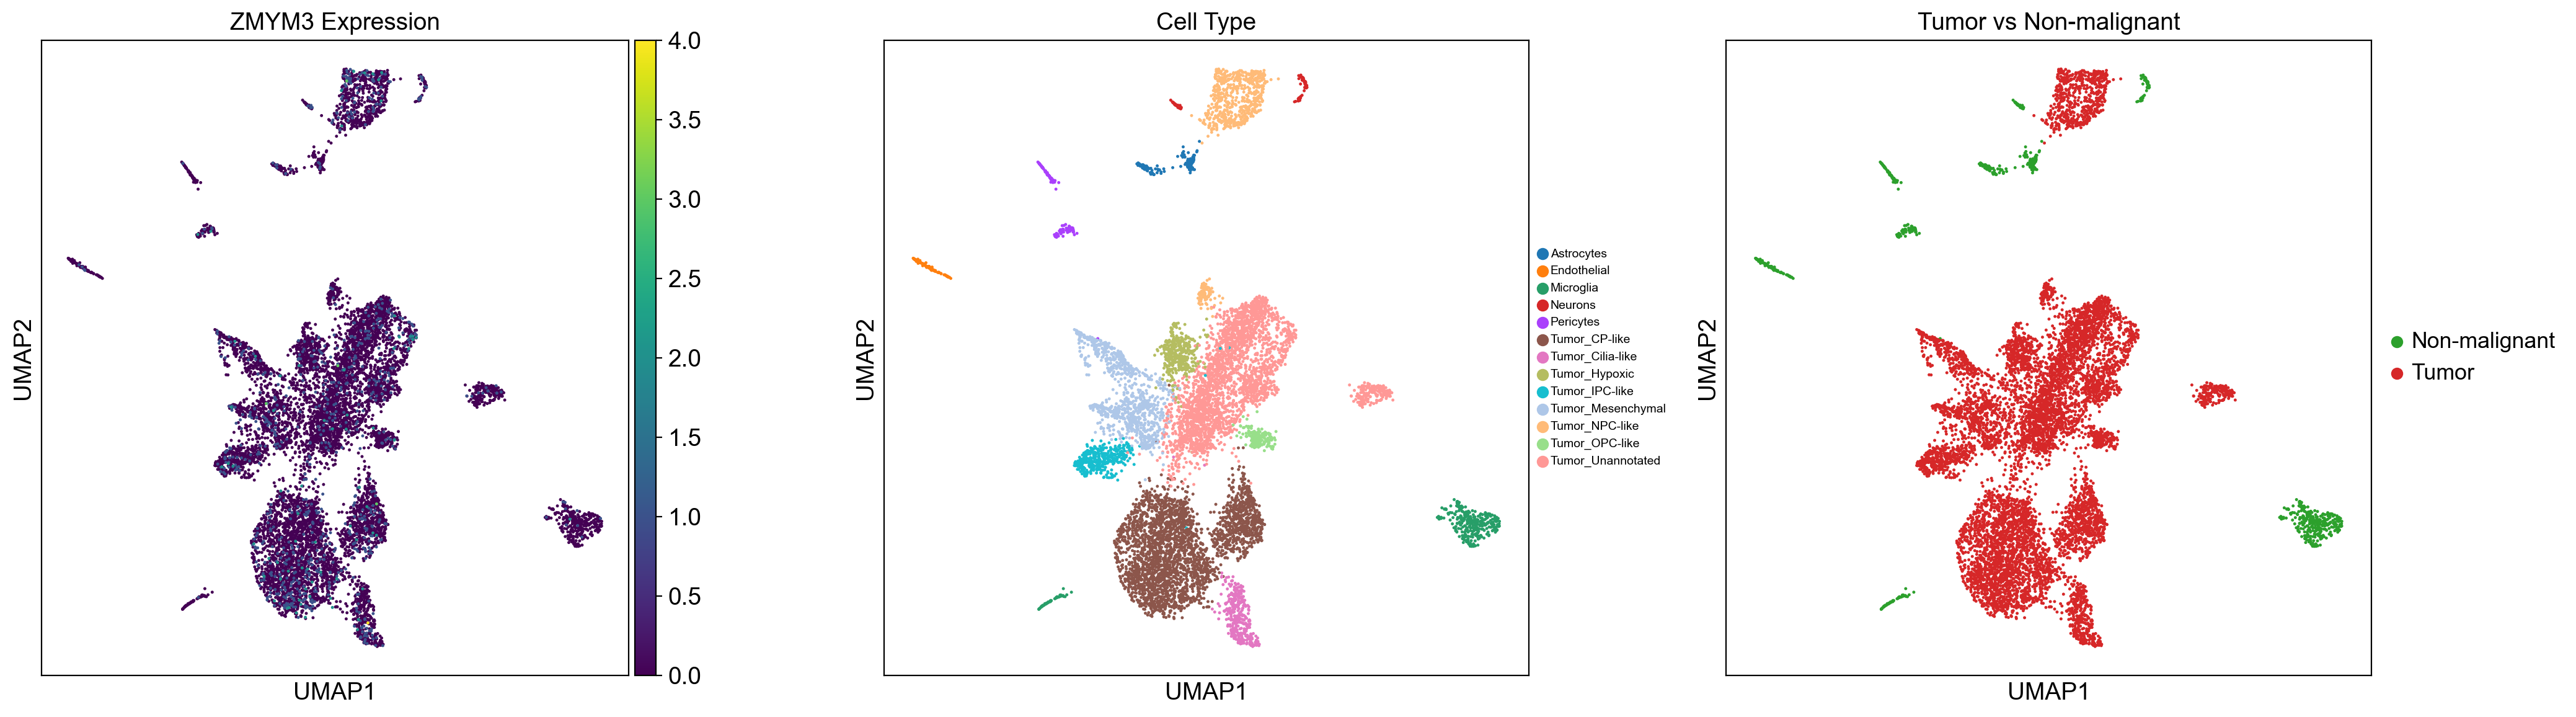


>>> FIGURE 2D: Saved to ~/ATRT/Data/Fig2D_ZMYM3_UMAP.png
>>> REPORT NOTE: 'Visualization of ZMYM3 expression across the integrated
>>>   UMAP embedding revealed detectable expression concentrated in tumor
>>>   cell clusters, with lower expression in non-malignant populations'


In [12]:
# ============================================================
# FIGURE FOR REPORT: ZMYM3 UMAP feature plot → Figure 2D
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sc.pl.umap(adata, color='ZMYM3', use_raw=True, ax=axes[0], show=False,
           title='ZMYM3 Expression', cmap='viridis', vmin=0)
sc.pl.umap(adata, color='cell_type', ax=axes[1], show=False, 
           title='Cell Type', legend_fontsize=7, legend_loc='right margin')
sc.pl.umap(adata, color='malignancy', ax=axes[2], show=False, 
           title='Tumor vs Non-malignant',
           palette={'Tumor': '#d62728', 'Non-malignant': '#2ca02c'})

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2D_ZMYM3_UMAP.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2D: Saved to ~/ATRT/Data/Fig2D_ZMYM3_UMAP.png")
print(">>> REPORT NOTE: 'Visualization of ZMYM3 expression across the integrated")
print(">>>   UMAP embedding revealed detectable expression concentrated in tumor")
print(">>>   cell clusters, with lower expression in non-malignant populations'")

Cell 3 — ZMYM3 violin plot per cell type (Figure 2E):

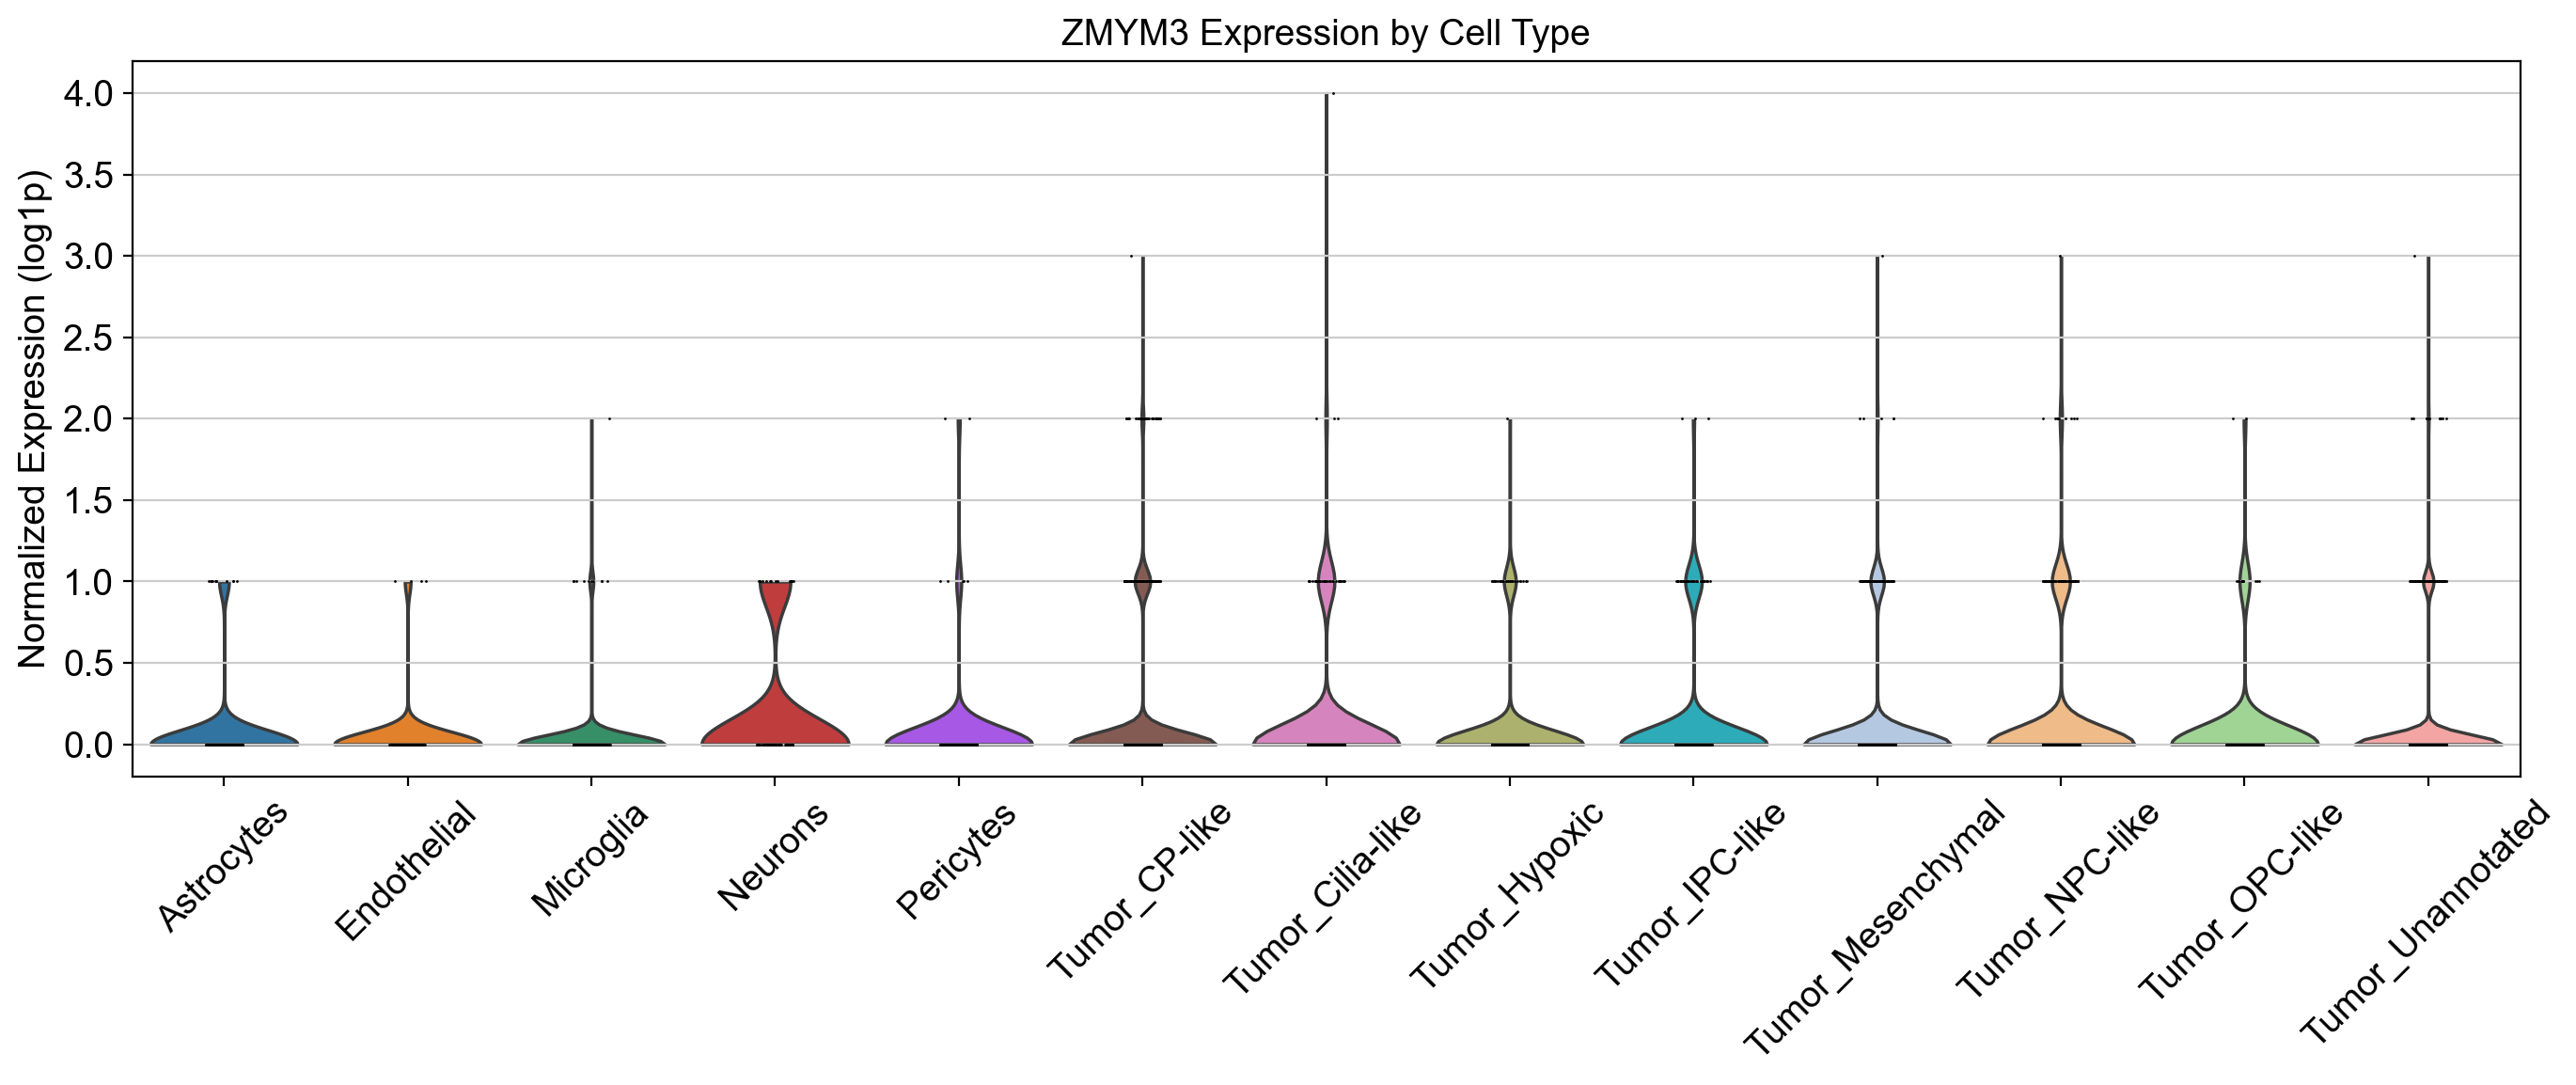


>>> FIGURE 2E: Saved to ~/ATRT/Data/Fig2E_ZMYM3_violin_celltype.png


In [13]:
# ============================================================
# FIGURE FOR REPORT: ZMYM3 violin plot per cell type → Figure 2E
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
sc.pl.violin(adata, keys='ZMYM3', groupby='cell_type', use_raw=True,
             rotation=45, ax=ax, show=False)
ax.set_title('ZMYM3 Expression by Cell Type')
ax.set_ylabel('Normalized Expression (log1p)')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2E_ZMYM3_violin_celltype.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2E: Saved to ~/ATRT/Data/Fig2E_ZMYM3_violin_celltype.png")

Cell 4 — Statistical test: tumor vs each non-malignant type:

In [14]:
# ============================================================
# STATISTICS: Wilcoxon rank-sum test for ZMYM3 expression
# Tumor cells vs each non-malignant cell type (BH-FDR correction)
# ============================================================

# Get ZMYM3 normalized expression from raw
zmym3_idx = list(adata.raw.var_names).index('ZMYM3')
zmym3_expr = adata.raw.X[:, zmym3_idx]
if hasattr(zmym3_expr, 'toarray'):
    zmym3_expr = zmym3_expr.toarray().flatten()
else:
    zmym3_expr = np.array(zmym3_expr).flatten()

adata.obs['ZMYM3_expr'] = zmym3_expr

# Tumor cell expression
tumor_mask = adata.obs['malignancy'] == 'Tumor'
tumor_expr = adata.obs.loc[tumor_mask, 'ZMYM3_expr']

# Non-malignant cell types
nonmal_types = [ct for ct in adata.obs['cell_type'].unique() 
                if not ct.startswith('Tumor')]

results = []
for ct in sorted(nonmal_types):
    ct_expr = adata.obs.loc[adata.obs['cell_type'] == ct, 'ZMYM3_expr']
    stat, pval = mannwhitneyu(tumor_expr, ct_expr, alternative='greater')
    
    tumor_median = tumor_expr.median()
    ct_median = ct_expr.median()
    # Log2 fold change of means (add pseudocount to avoid log(0))
    tumor_mean = tumor_expr.mean()
    ct_mean = ct_expr.mean()
    log2fc = np.log2((tumor_mean + 0.01) / (ct_mean + 0.01))
    
    results.append({
        'Cell_Type': ct,
        'N_cells': len(ct_expr),
        'Tumor_median': tumor_median,
        'Ref_median': ct_median,
        'Tumor_mean': tumor_mean,
        'Ref_mean': ct_mean,
        'Log2FC': log2fc,
        'U_statistic': stat,
        'p_value': pval
    })

results_df = pd.DataFrame(results)

# BH-FDR correction
reject, fdr_pvals, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['FDR'] = fdr_pvals
results_df['Significant'] = reject

print("=== ZMYM3: Tumor vs Non-malignant Cell Types ===")
print("(Wilcoxon rank-sum test, one-sided: tumor > reference)\n")
print(results_df.to_string(index=False, float_format='%.4f'))

# ============================================================
# REPORT VALUES for Results section
# ============================================================
print(f"\n>>> FOR REPORT:")
print(f">>> All comparisons significant after BH-FDR: {results_df['Significant'].all()}")
print(f">>> Tumor cell median ZMYM3: {tumor_expr.median():.4f}")
print(f">>> Tumor cell mean ZMYM3: {tumor_expr.mean():.4f}")
print(f">>> % tumor cells expressing ZMYM3: {(tumor_expr > 0).sum() / len(tumor_expr) * 100:.1f}%")

# Expression ratio (tumor vs highest non-malignant)
highest_nonmal = results_df.loc[results_df['Ref_mean'].idxmax()]
ratio = tumor_expr.mean() / (highest_nonmal['Ref_mean'] + 0.001)
print(f"\n>>> Highest-expressing non-malignant type: {highest_nonmal['Cell_Type']}")
print(f">>>   Mean expression: {highest_nonmal['Ref_mean']:.4f}")
print(f">>> Expression ratio (tumor / highest non-malignant): {ratio:.2f}x")

=== ZMYM3: Tumor vs Non-malignant Cell Types ===
(Wilcoxon rank-sum test, one-sided: tumor > reference)

  Cell_Type  N_cells  Tumor_median  Ref_median  Tumor_mean  Ref_mean  Log2FC  U_statistic  p_value    FDR  Significant
 Astrocytes      177        0.0000      0.0000      0.1024    0.0621  0.6392  793694.0000   0.0759 0.0949        False
Endothelial      105        0.0000      0.0000      0.1024    0.0381  1.2243  481720.0000   0.0258 0.0430         True
  Microglia      386        0.0000      0.0000      0.1024    0.0311  1.4515 1786459.5000   0.0000 0.0000         True
    Neurons       87        0.0000      0.0000      0.1024    0.1724 -0.6990  348774.0000   0.9933 0.9933        False
  Pericytes      155        0.0000      0.0000      0.1024    0.0581  0.7233  705585.0000   0.0222 0.0430         True

>>> FOR REPORT:
>>> All comparisons significant after BH-FDR: False
>>> Tumor cell median ZMYM3: 0.0000
>>> Tumor cell mean ZMYM3: 0.1024
>>> % tumor cells expressing ZMYM3: 9.3%



Cell 5 — ZMYM3 expression across AT/RT subgroups (Figure 2F):

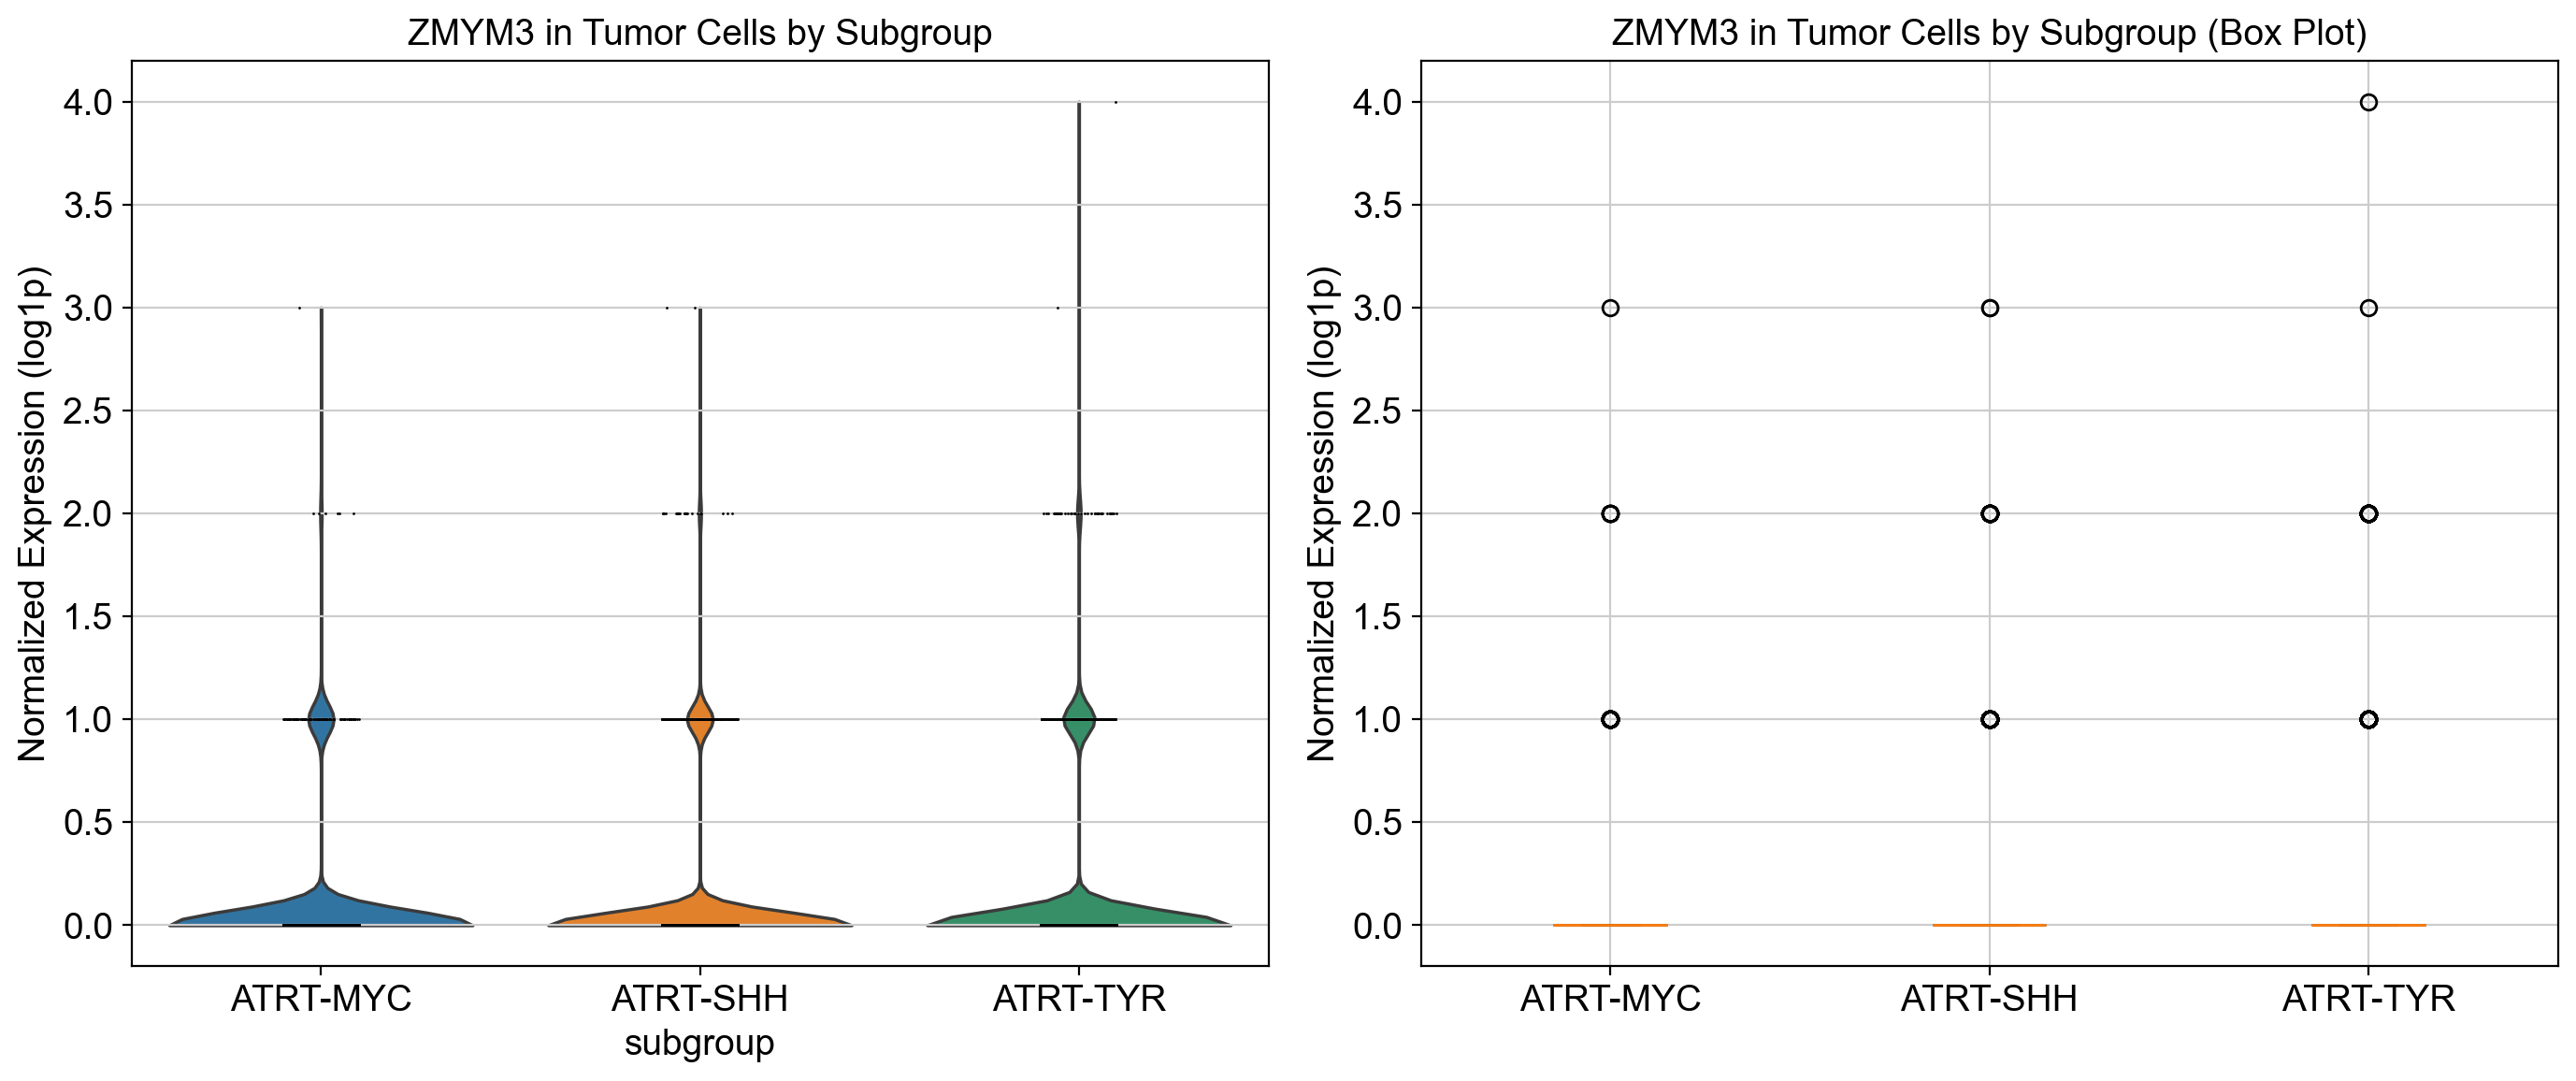


>>> FIGURE 2F: Saved to ~/ATRT/Data/Fig2F_ZMYM3_subgroups.png


In [15]:
# ============================================================
# FIGURE FOR REPORT: ZMYM3 across subgroups → Figure 2F
# ============================================================

# Filter to tumor cells only
tumor = adata[adata.obs['malignancy'] == 'Tumor'].copy()
tumor.obs['ZMYM3_expr'] = adata.obs.loc[tumor.obs_names, 'ZMYM3_expr']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot by subgroup
sc.pl.violin(tumor, keys='ZMYM3', groupby='subgroup', use_raw=True,
             ax=axes[0], show=False)
axes[0].set_title('ZMYM3 in Tumor Cells by Subgroup')
axes[0].set_ylabel('Normalized Expression (log1p)')

# Box plot for clearer median comparison
subgroup_data = []
subgroup_labels = []
for sg in sorted(tumor.obs['subgroup'].unique()):
    expr = tumor.obs.loc[tumor.obs['subgroup'] == sg, 'ZMYM3_expr']
    subgroup_data.append(expr.values)
    subgroup_labels.append(sg)

bp = axes[1].boxplot(subgroup_data, labels=subgroup_labels, patch_artist=True)
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']  # MYC, SHH, TYR
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('ZMYM3 in Tumor Cells by Subgroup (Box Plot)')
axes[1].set_ylabel('Normalized Expression (log1p)')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2F_ZMYM3_subgroups.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2F: Saved to ~/ATRT/Data/Fig2F_ZMYM3_subgroups.png")

Cell 6 — Kruskal-Wallis test across subgroups:

In [16]:
# ============================================================
# STATISTICS: Kruskal-Wallis + post-hoc Dunn's test
# ZMYM3 across AT/RT subgroups within tumor cells
# ============================================================

from itertools import combinations

# Kruskal-Wallis test
groups = []
for sg in sorted(tumor.obs['subgroup'].unique()):
    expr = tumor.obs.loc[tumor.obs['subgroup'] == sg, 'ZMYM3_expr'].values
    groups.append(expr)
    
kw_stat, kw_pval = kruskal(*groups)
print(f"Kruskal-Wallis test across subgroups:")
print(f"  H-statistic: {kw_stat:.4f}")
print(f"  p-value: {kw_pval:.4e}")

# Per-subgroup summary
print(f"\n=== Per-subgroup ZMYM3 expression (tumor cells only) ===")
for sg in sorted(tumor.obs['subgroup'].unique()):
    expr = tumor.obs.loc[tumor.obs['subgroup'] == sg, 'ZMYM3_expr']
    pct = (expr > 0).sum() / len(expr) * 100
    print(f"\n{sg}:")
    print(f"  N tumor nuclei: {len(expr)}")
    print(f"  % expressing: {pct:.1f}%")
    print(f"  Mean: {expr.mean():.4f}")
    print(f"  Median: {expr.median():.4f}")

# Post-hoc pairwise Wilcoxon tests with BH correction
print(f"\n=== Post-hoc pairwise comparisons (Wilcoxon, BH-FDR) ===")
subgroup_names = sorted(tumor.obs['subgroup'].unique())
pairwise_results = []
for sg1, sg2 in combinations(subgroup_names, 2):
    expr1 = tumor.obs.loc[tumor.obs['subgroup'] == sg1, 'ZMYM3_expr']
    expr2 = tumor.obs.loc[tumor.obs['subgroup'] == sg2, 'ZMYM3_expr']
    stat, pval = mannwhitneyu(expr1, expr2, alternative='two-sided')
    pairwise_results.append({'Comparison': f'{sg1} vs {sg2}', 'U': stat, 'p_value': pval})

pw_df = pd.DataFrame(pairwise_results)
reject, fdr_pvals, _, _ = multipletests(pw_df['p_value'], method='fdr_bh')
pw_df['FDR'] = fdr_pvals
pw_df['Significant'] = reject
print(pw_df.to_string(index=False, float_format='%.4e'))

# ============================================================
# REPORT VALUES
# ============================================================
print(f"\n>>> FOR REPORT:")
print(f">>> Kruskal-Wallis p = {kw_pval:.4e}")
if kw_pval > 0.05:
    print(f">>> ZMYM3 expression is NOT significantly different across subgroups")
    print(f">>> This SUPPORTS pan-subgroup vulnerability!")
else:
    print(f">>> ZMYM3 expression differs significantly across subgroups")
    print(f">>> Check pairwise comparisons above for details")

Kruskal-Wallis test across subgroups:
  H-statistic: 10.4301
  p-value: 5.4340e-03

=== Per-subgroup ZMYM3 expression (tumor cells only) ===

ATRT-MYC:
  N tumor nuclei: 1354
  % expressing: 8.2%
  Mean: 0.0879
  Median: 0.0000

ATRT-SHH:
  N tumor nuclei: 3462
  % expressing: 8.5%
  Mean: 0.0927
  Median: 0.0000

ATRT-TYR:
  N tumor nuclei: 3878
  % expressing: 10.4%
  Mean: 0.1160
  Median: 0.0000

=== Post-hoc pairwise comparisons (Wilcoxon, BH-FDR) ===
          Comparison          U    p_value        FDR  Significant
ATRT-MYC vs ATRT-SHH 2.3359e+06 7.0632e-01 7.0632e-01        False
ATRT-MYC vs ATRT-TYR 2.5662e+06 1.6482e-02 2.4723e-02         True
ATRT-SHH vs ATRT-TYR 6.5840e+06 5.2051e-03 1.5615e-02         True

>>> FOR REPORT:
>>> Kruskal-Wallis p = 5.4340e-03
>>> ZMYM3 expression differs significantly across subgroups
>>> Check pairwise comparisons above for details


Cell 7 — On-target/off-tumor expression ratio:

In [17]:
# ============================================================
# REPORT VALUES: Therapeutic selectivity assessment
# ============================================================

print("=== On-target / Off-tumor Expression Assessment ===\n")

# Per non-malignant cell type
print(f"{'Cell Type':<25} {'N':>6} {'% Expressing':>13} {'Mean Expr':>10} {'Median Expr':>12}")
print("-" * 70)

for ct in sorted(nonmal_types):
    ct_expr = adata.obs.loc[adata.obs['cell_type'] == ct, 'ZMYM3_expr']
    pct = (ct_expr > 0).sum() / len(ct_expr) * 100
    print(f"{ct:<25} {len(ct_expr):>6} {pct:>12.1f}% {ct_expr.mean():>10.4f} {ct_expr.median():>12.4f}")

print("-" * 70)
print(f"{'TUMOR CELLS':<25} {tumor_mask.sum():>6} "
      f"{(tumor_expr > 0).sum() / len(tumor_expr) * 100:>12.1f}% "
      f"{tumor_expr.mean():>10.4f} {tumor_expr.median():>12.4f}")

# Overall selectivity
max_nonmal_mean = max(
    adata.obs.loc[adata.obs['cell_type'] == ct, 'ZMYM3_expr'].mean() 
    for ct in nonmal_types
)
selectivity = tumor_expr.mean() / (max_nonmal_mean + 0.001)
print(f"\n>>> SELECTIVITY RATIO (tumor mean / highest non-malignant mean): {selectivity:.2f}x")
print(f">>> REPORT NOTE: 'The ratio of mean ZMYM3 expression in tumor cells")
print(f">>>   versus the highest-expressing non-malignant population provides")
print(f">>>   a quantitative estimate of therapeutic selectivity'")

=== On-target / Off-tumor Expression Assessment ===

Cell Type                      N  % Expressing  Mean Expr  Median Expr
----------------------------------------------------------------------
Astrocytes                   177          6.2%     0.0621       0.0000
Endothelial                  105          3.8%     0.0381       0.0000
Microglia                    386          2.8%     0.0311       0.0000
Neurons                       87         17.2%     0.1724       0.0000
Pericytes                    155          4.5%     0.0581       0.0000
----------------------------------------------------------------------
TUMOR CELLS                 8694          9.3%     0.1024       0.0000

>>> SELECTIVITY RATIO (tumor mean / highest non-malignant mean): 0.59x
>>> REPORT NOTE: 'The ratio of mean ZMYM3 expression in tumor cells
>>>   versus the highest-expressing non-malignant population provides
>>>   a quantitative estimate of therapeutic selectivity'


Cell 8 — Save:

In [ ]:
# Save for Program 7 (Co-expression & GSEA)
output_path = os.path.expanduser("~/ATRT/Data/adata_ZMYM3_analyzed.h5ad")
adata.write(output_path)
print(f"AnnData saved to: {output_path}")

print(f"\n>>> Program 6 complete!")
print(f">>> Key deliverables:")
print(f">>>   - Figure 2D: ZMYM3 UMAP feature plot")
print(f">>>   - Figure 2E: ZMYM3 violin plot by cell type")
print(f">>>   - Figure 2F: ZMYM3 expression across subgroups")
print(f">>>   - Statistical tests: Wilcoxon (tumor vs non-malignant)")
print(f">>>   - Statistical tests: Kruskal-Wallis (across subgroups)")
print(f">>>   - Selectivity ratio for therapeutic window")
print(f"\n>>> Next: Program 7 (Co-expression Analysis & GSEA)")